In [1]:
from src.eval.retrievers import search_clip_only, search_clip_dense, search_hybrid_image, search_dense_text, search_hybrid_text
from src.eval.retrieval_metrics import  run_retrieval_experiment
from src.config import settings
import pandas as pd
from src.rag.llm_service import LLMService
from src.eval.generation_runner import run_generation_eval
from src.eval.retrievers import storage, embedder
from langchain_openai import AzureChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
df_text_eval = pd.read_parquet(settings.EVAL_TEXTS_DF_PATH)
df_image_eval = pd.read_parquet(settings.EVAL_IMAGES_DF_PATH)

In [3]:
K = 5

# 1. Text Evaluation
text_results = []
text_results.append(run_retrieval_experiment("Dense Only", search_dense_text, df_text_eval, k=K))
text_results.append(run_retrieval_experiment("Hybrid (DENSE+SPARSE)", search_hybrid_text, df_text_eval, k=K))

df_text_res = pd.DataFrame(text_results)

# 2. Image Evaluation
image_results = []
image_results.append(run_retrieval_experiment("CLIP and DENSE", search_clip_dense, df_image_eval, k=K, is_image_search=True))
image_results.append(run_retrieval_experiment("Hybrid (CLIP+DENSE+SPARSE)", search_hybrid_image, df_image_eval, k=K, is_image_search=True))

df_image_res = pd.DataFrame(image_results)

In [4]:
from src.eval.plots import plot_metrics

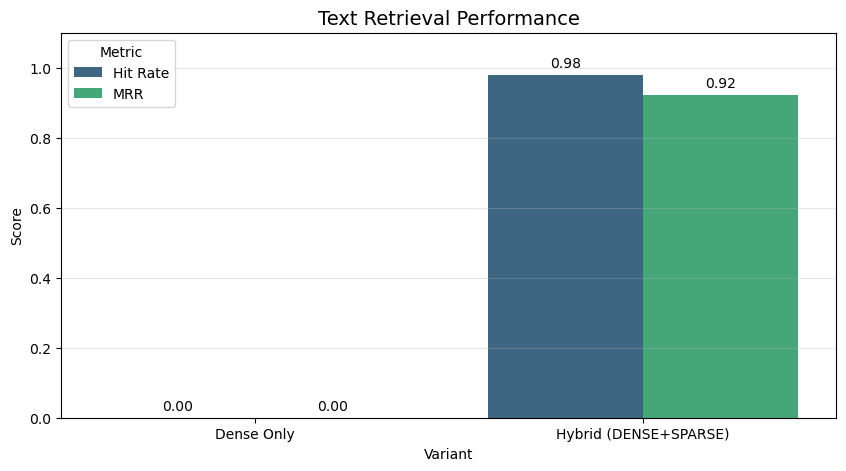

In [5]:
plot_metrics(df_text_res, "Text Retrieval Performance")

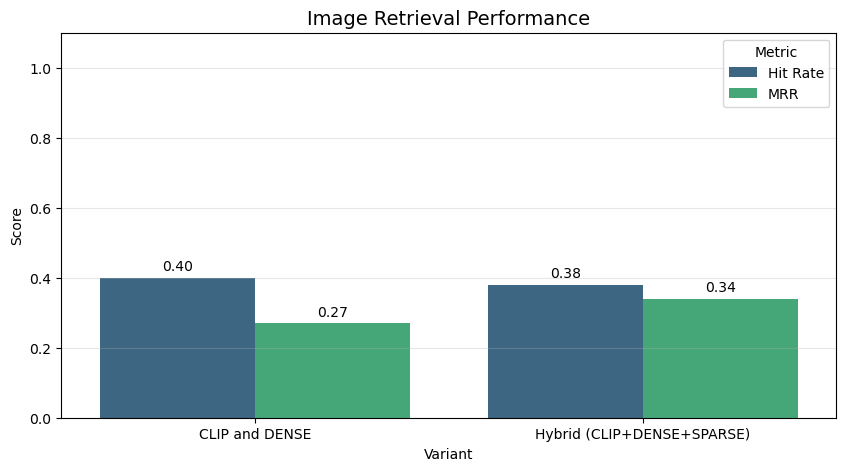

In [6]:
plot_metrics(df_image_res, "Image Retrieval Performance")

In [ ]:
llm_service = LLMService(storage=storage)

judge_llm = AzureChatOpenAI(
    azure_deployment="gpt-4o",
    azure_endpoint="https://case-synthesizer.cognitiveservices.azure.com/",
    api_key=os.getenv('AZURE_OPENAI_API_KEY'),
    api_version="2024-05-01-preview",
    temperature=0
)

print("Services initialized.")

print(f"Starting generation evaluation on {len(df_text_eval)} samples...")

df_gen_eval = run_generation_eval(
    llm_service=llm_service,
    judge_llm=judge_llm,
    embedder=embedder,
    dataset=df_text_eval
)

print("Evaluation complete.")

29-Jan-26 19:20:32 - INFO - Model ended generating response


In [ ]:
df_gen_eval.head()

In [ ]:
from src.eval.plots import plot_extended_metrics

plot_extended_metrics(df_gen_eval)